## **Name:** Smriddhi Gupta
## **Matriculation Number:** 84530018
## **Course:** B.Sc. Digital Business and Data Science (Semester 4)

# **Random Forest: Machine Failure Prediction**

In [74]:
# Import packages
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [75]:
# Loading the dataset into the python notebook
# Read the CSV file into a pandas DataFrame.
# The dataset contains 10,000 rows and 14 columns, representing synthetic industrial machine sensor readings and failure labels.
df = pd.read_csv('Machine_failure (1).csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [76]:
# Print the number of rows and columns, expected: (10000, 14)
print(df.shape)
# df.info() reveals column names, data types, and whether any values are missing.
df.info()

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(

In [77]:
# Check how many machines failed (1) vs. did not fail (0).
# This reveals class imbalance — in this dataset, failures are rare (~3.4%), which means the model could achieve ~97% accuracy just by always predicting 'No Failure'.
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [134]:
# The 'Type' column contains string values L (Low), M (Medium), H (High).
# Random Forest requires all input features to be numeric, so we encode these string labels as integers using LabelEncoder.
# LabelEncoder automatically assigns: H=0, L=1, M=2 (alphabetical order)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

# Confirm encoding — should show 3 unique values (0, 1, 2) with no NaNs
print("Classes encoded:", le.classes_)
print(df['Type'].value_counts())
df.head()

Classes encoded: [0]
Type
0    10000
Name: count, dtype: int64


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,0,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0


In [79]:
# TWF, HDF, PWF, OSF, RNF are the five individual failure mode flags.
# These columns are dropped to prevent data leakage: they are sub-components
# that directly determine the 'Machine failure' target variable.
df = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0


In [103]:
# X contains all input features the model will learn from: Type, Air temperature, Process temperature, Rotational speed, Torque, Tool wear
X = df.drop('Machine failure', axis='columns')

# y is the binary target variable we want to predict: 0 = No Failure, 1 = Machine Failure
y = df['Machine failure']

# Preview feature set to confirm the split is correct
X.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,0,298.1,308.6,1551,42.8,0
1,0,298.2,308.7,1408,46.3,3
2,0,298.1,308.5,1498,49.4,5
3,0,298.2,308.6,1433,39.5,7
4,0,298.2,308.7,1408,40.0,9


In [104]:
# 80% of the data is used to train the model; 20% is held back for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes to confirm the split
print(X_train.shape, X_test.shape)

(8000, 6) (2000, 6)


In [105]:
# RandomForestClassifier builds an ensemble of decision trees.
# n_estimators=200: the forest uses 200 individual decision trees.
# class_weight='balanced': automatically adjusts the weight of each class inversely proportional to its frequency. Since failures are rare (~3.4%),
# This prevents the model from simply ignoring the minority class and ensures it learns to detect actual failures, which is the whole point of the task.
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

# Fit the model on the training data and this is where the trees are built
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [106]:
# model.score() returns the proportion of correct predictions on the test set.
# Test the model
model.score(X_test, y_test)

0.983

In [107]:
# Importing packages
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sn
import matplotlib.pyplot as plt

In [108]:
# model.predict() uses the trained forest to classify each row in the test set.
# Each tree casts a vote (0 or 1), and the majority vote becomes the final prediction.
y_predicted = model.predict(X_test)

# Print all predicted values
print(y_predicted)

[0 0 0 ... 0 1 0]


In [109]:
# The classification report is a more meaningful evaluation metric than accuracy alone, especially for imbalanced datasets.
print(classification_report(y_test, y_predicted, target_names=['No Failure', 'Failure']))

              precision    recall  f1-score   support

  No Failure       0.98      1.00      0.99      1939
     Failure       0.91      0.49      0.64        61

    accuracy                           0.98      2000
   macro avg       0.95      0.75      0.81      2000
weighted avg       0.98      0.98      0.98      2000



In [110]:
# The confusion matrix breaks down predictions into four categories:
# True Negatives  (top-left):  correctly predicted No Failure
# False Positives (top-right): predicted Failure, but was actually No Failure
# False Negatives (bottom-left): predicted No Failure, but was actually a Failure
# True Positives  (bottom-right): correctly predicted Failure
cm = confusion_matrix(y_test, y_predicted)
print(cm)

[[1936    3]
 [  31   30]]


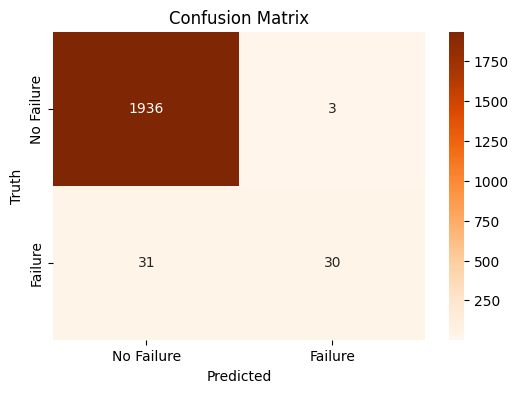

In [114]:
# A heatmap makes the confusion matrix easier to read at a glance.
# annot = True prints the actual counts inside each cell.
# fmt = 'd' formats numbers as integers (no decimals).
# cmap = 'Oranges' uses a orange color gradient , darker = higher count.
plt.figure(figsize=(6, 4))
sn.heatmap(cm, annot = True, fmt = 'd', cmap = 'Oranges',
           xticklabels = ['No Failure', 'Failure'],
           yticklabels = ['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()

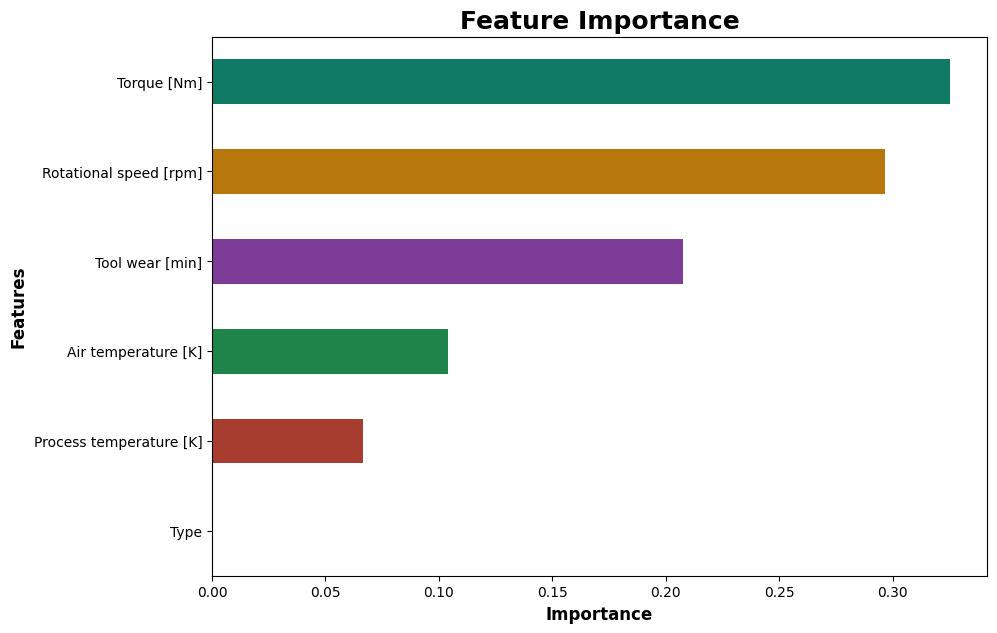

In [118]:
# After training, each feature is assigned an importance score reflecting how much it contributed to reducing impurity across all decision trees.
# Higher importance = the feature was more useful for making correct splits.
# Sorting ascending = True, means the most important feature appears at the top of the horizontal bar chart.
# This helps us understand which sensor readings are most predictive of failure.
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
colors = ['#1B6CA8', '#A63D2F', '#1E8449', '#7D3C98', '#B7770D', '#117A65']

feat_imp.plot(kind='barh', color=colors, figsize=(10, 7))
plt.title('Feature Importance', fontsize=18, fontweight='bold')
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.show()